In [8]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms import functional as TF

def _sorted_frames(video_dir: Path) -> List[Path]:
    """Return sorted .jpg frames (lexical order)."""
    frames = [p for p in video_dir.iterdir() if p.suffix.lower() == ".jpg"]
    return sorted(frames, key=lambda p: p.name)

@dataclass
class _Clip:
    video_id: str
    indices: List[int]
    label: Optional[int]

class IPNHandFrames(Dataset):
    def __init__(
        self,
        frames_root: str | Path,
        annot_file: str | Path,
        clip_len: int = 16,
        resize_to: tuple[int,int] = (224,224),
        normalize: bool = True,
    ):
        self.root = Path(frames_root)
        self.clip_len = clip_len
        self.resize_to = resize_to
        self.normalize = normalize

        # Load video dirs
        self.videos: Dict[str, List[Path]] = {}
        for d in sorted(p for p in self.root.iterdir() if p.is_dir()):
            frames = _sorted_frames(d)
            if frames:
                self.videos[d.name] = frames

        # Parse annotations
        self.clips: List[_Clip] = []
        with open(annot_file, "r", encoding="utf-8") as f:
            for line in f:
                row = [x.strip() for x in line.strip().split(",")]
                if not row or row[0].startswith("#"):
                    continue
                vid = row[0]
                if vid not in self.videos:
                    continue
                try:
                    class_id = int(row[2]) if row[2] else -1
                except Exception:
                    class_id = -1
                try:
                    start1 = int(row[3])  # 1-based
                    end1   = int(row[4])  # 1-based
                except Exception:
                    n = len(self.videos[vid])
                    start1, end1 = 1, n

                frames = self.videos[vid]
                n = len(frames)
                seg_start0 = max(0, start1 - 1)
                seg_end0   = min(n, end1)
                if seg_end0 - seg_start0 < self.clip_len:
                    idxs = list(range(seg_start0, seg_end0))
                else:
                    mid = (seg_start0 + seg_end0 - self.clip_len) // 2
                    idxs = list(range(mid, mid + self.clip_len))
                self.clips.append(_Clip(vid, idxs, class_id))

    def __len__(self): return len(self.clips)

    def _load_frame(self, path: Path) -> torch.Tensor:
        img = read_image(str(path)).float() / 255.0
        if self.resize_to:
            img = TF.resize(img, self.resize_to, antialias=True)
        if self.normalize:
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            img = (img - mean) / std
        return img

    def __getitem__(self, i: int):
        clip = self.clips[i]
        frames = self.videos[clip.video_id]
        imgs = [self._load_frame(frames[k]) for k in clip.indices if k < len(frames)]
        x = torch.stack(imgs, dim=0)   # [T,C,H,W]
        y = torch.tensor(clip.label, dtype=torch.long)
        return {"video_id": clip.video_id, "frames": x, "label": y}

def pad_collate(batch: Sequence[dict]):
    vids = [b["video_id"] for b in batch]
    ys   = torch.stack([b["label"] for b in batch])
    xs   = [b["frames"] for b in batch]
    T    = max(t.shape[0] for t in xs)
    C,H,W = xs[0].shape[1:]
    out  = torch.zeros((len(xs), T, C, H, W), dtype=xs[0].dtype)
    for i, t in enumerate(xs):
        out[i, :t.shape[0]] = t
        if t.shape[0] < T:
            out[i, t.shape[0]:] = t[-1:]
    return {"video_id": vids, "frames": out, "label": ys}

FRAMES_ROOT = "frames"
ANNOT_FILE  = "annotations/Annot_TrainList.txt"

ds = IPNHandFrames(
    frames_root=FRAMES_ROOT,
    annot_file=ANNOT_FILE,
    clip_len=16,
)

dl = DataLoader(
    ds,
    batch_size=4,
    shuffle=True,
    num_workers=0,   # <-- safe for Jupyter
    collate_fn=pad_collate,
)

# Print one batch shape
batch = next(iter(dl))
print("Frames:", batch["frames"].shape)  # [B,T,C,H,W]
print("Labels:", batch["label"].shape)
print("Video IDs:", batch["video_id"])


Frames: torch.Size([4, 16, 3, 224, 224])
Labels: torch.Size([4])
Video IDs: ['1CV12_13_R_#93', '4CM11_2_R_#40', '4CM11_15_R_#25', '1CV12_22_R_#115']


In [ ]:
total_frames = sum(len(frames) for frames in ds.videos.values())
print(f"Total videos: {len(ds.videos)}")
print(f"Total frames: {total_frames}")
print(f"Total clips: {len(ds)}")

Total videos: 200
Total frames: 800491
Total clips (dataset length): 4039


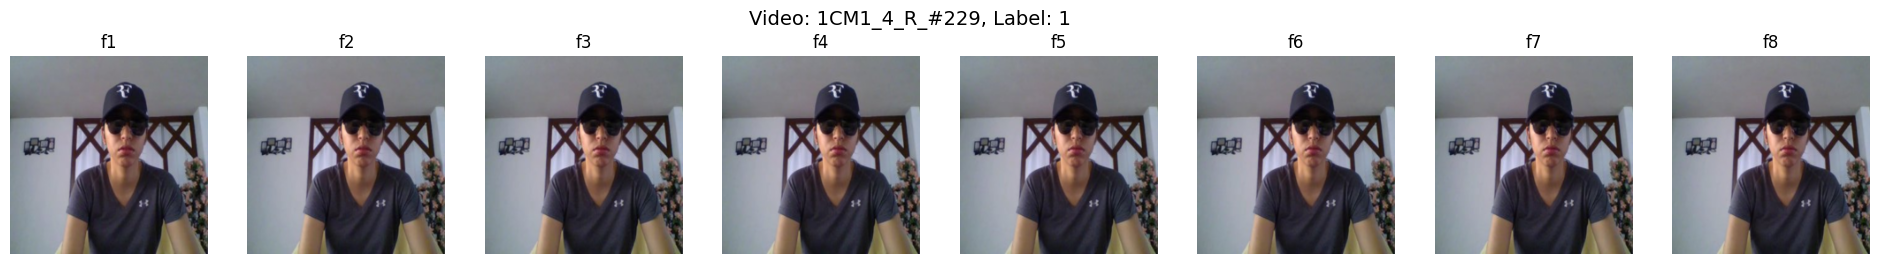

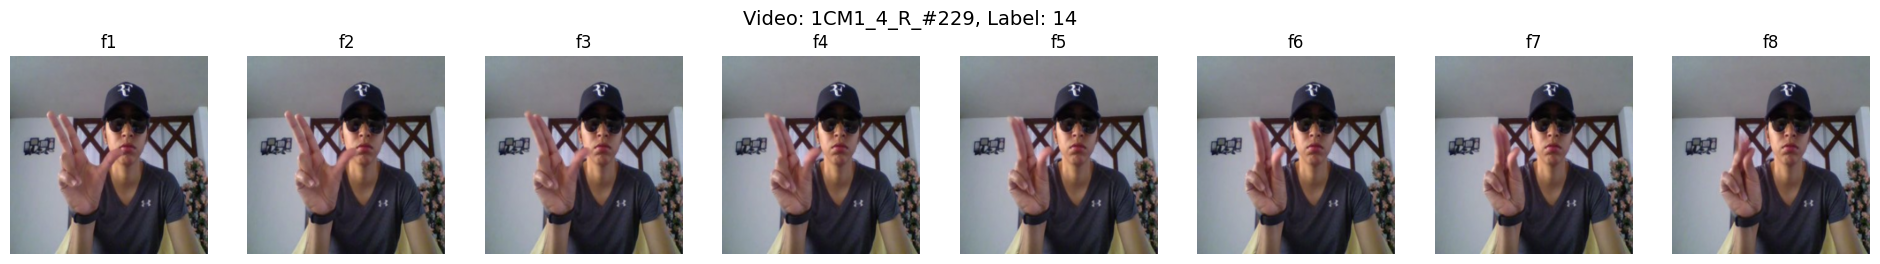

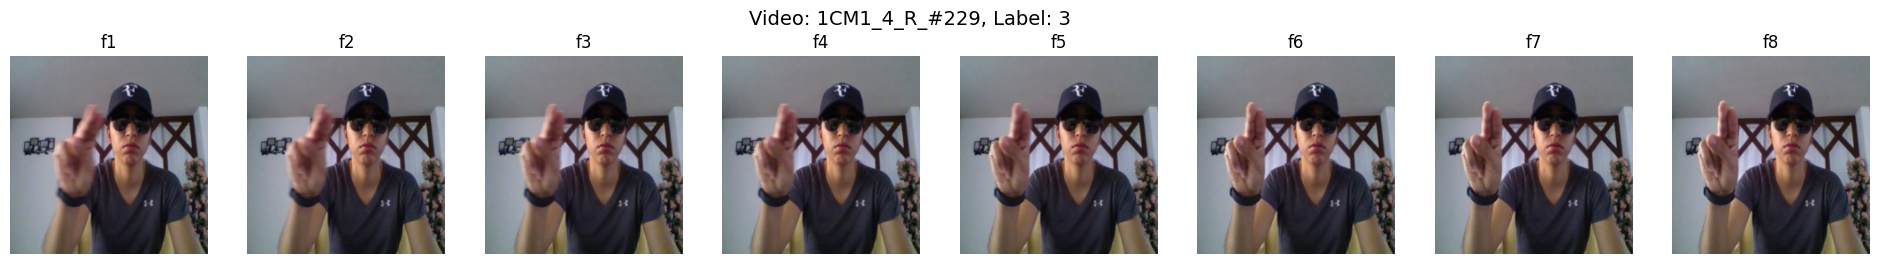

In [ ]:
import matplotlib.pyplot as plt

def show_clip(batch_item, max_frames=8):
    frames = batch_item["frames"]  # [T,C,H,W]
    label = batch_item["label"].item()
    vid   = batch_item["video_id"]

    T = min(frames.shape[0], max_frames)
    fig, axes = plt.subplots(1, T, figsize=(3*T, 3))
    if T == 1:
        axes = [axes]
    for i in range(T):
        img = frames[i].permute(1,2,0)  # CHW -> HWC
        img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])
        img = img.clamp(0,1)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"f{i+1}")
    fig.suptitle(f"Video: {vid}, Label: {label}", fontsize=14)
    plt.show()

for i in range(3):
    item = ds[i]
    show_clip(item, max_frames=8)